In [13]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Directorios
# ---------------------------------------------------------

BASE_DIR = Path.cwd().parent
RESULTS_DIR = BASE_DIR / "results"
FIGURES_DIR = BASE_DIR / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# BookTection:
# DE-COP vs. SimMIA
# ---------------------------------------------------------

DECOP_BOOKTECTION_METRICS_PATH = (
    RESULTS_DIR
    / "decop"
    / "llama-3.1-8b-instant"
    / "decop_metrics_summary.csv"
)

DECOP_BOOKTECTION_SAMPLES_PATH = (
    RESULTS_DIR
    / "decop"
    / "llama-3.1-8b-instant"
    / "decop_sample_level_results.csv"
)

SIMMIA_BOOKTECTION_METRICS_PATH = (
    RESULTS_DIR
    / "simmia"
    / "llama-3.1-8b-instant"
    / "simmia_metrics_summary.csv"
)

SIMMIA_BOOKTECTION_SAMPLES_PATH = (
    RESULTS_DIR
    / "simmia"
    / "llama-3.1-8b-instant"
    / "simmia_sample_level_results.csv"
)

# ---------------------------------------------------------
# WikiMIA:
# DE-COP, para comparar luego con DUALTEST
# ---------------------------------------------------------

DECOP_WIKIMIA_METRICS_PATH = (
    RESULTS_DIR
    / "decop_wikimia128_3options"
    / "llama-3.1-8b-instant"
    / "decop_metrics_summary.csv"
)

DECOP_WIKIMIA_SAMPLES_PATH = (
    RESULTS_DIR
    / "decop_wikimia128_3options"
    / "llama-3.1-8b-instant"
    / "decop_sample_level_results.csv"
)

# ---------------------------------------------------------
# Verificar rutas
# ---------------------------------------------------------

paths = [
    DECOP_BOOKTECTION_METRICS_PATH,
    DECOP_BOOKTECTION_SAMPLES_PATH,
    SIMMIA_BOOKTECTION_METRICS_PATH,
    SIMMIA_BOOKTECTION_SAMPLES_PATH,
    DECOP_WIKIMIA_METRICS_PATH,
    DECOP_WIKIMIA_SAMPLES_PATH,
]

for path in paths:
    if not path.exists():
        raise FileNotFoundError(f"No se encontró el archivo: {path}")

# ---------------------------------------------------------
# Cargar métricas
# ---------------------------------------------------------

decop_booktection_metrics = pd.read_csv(
    DECOP_BOOKTECTION_METRICS_PATH
).iloc[0]

simmia_booktection_metrics = pd.read_csv(
    SIMMIA_BOOKTECTION_METRICS_PATH
).iloc[0]

decop_wikimia_metrics = pd.read_csv(
    DECOP_WIKIMIA_METRICS_PATH
).iloc[0]

In [14]:
booktection_summary_df = pd.DataFrame([
    {
        "Método": "DE-COP",
        "Modelo": decop_booktection_metrics["model"],
        "Dataset": "BookTection medium",
        "AUC": float(decop_booktection_metrics["auc"]),
        "Muestras": int(decop_booktection_metrics["n_samples"]),
    },
    {
        "Método": "SimMIA",
        "Modelo": simmia_booktection_metrics["model"],
        "Dataset": "BookTection medium",
        "AUC": float(simmia_booktection_metrics["auc"]),
        "Muestras": int(simmia_booktection_metrics["n_samples"]),
    },
])

display(booktection_summary_df)

booktection_summary_path = (
    FIGURES_DIR / "booktection_decop_simmia_summary.csv"
)

booktection_summary_df.to_csv(
    booktection_summary_path,
    index=False,
)

print("Tabla BookTection guardada en:")
print(booktection_summary_path)

,Método,Modelo,Dataset,AUC,Muestras
0,DE-COP,llama-3.1-8b-instant,BookTection medium,0.77565,200
1,SimMIA,llama-3.1-8b-instant,BookTection medium,0.52010,200


Tabla BookTection guardada en:
/Users/florenciazoffi/Desktop/code/sietesemestre/nlp/NLP_Proyecto_Final/simmia_decop/figures/booktection_decop_simmia_summary.csv


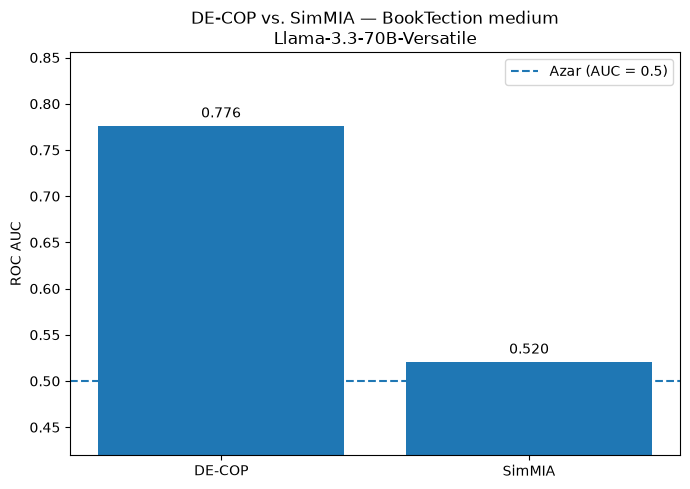

PNG guardado en: /Users/florenciazoffi/Desktop/code/sietesemestre/nlp/NLP_Proyecto_Final/simmia_decop/figures/auc_booktection_decop_simmia.png
PDF guardado en: /Users/florenciazoffi/Desktop/code/sietesemestre/nlp/NLP_Proyecto_Final/simmia_decop/figures/auc_booktection_decop_simmia.pdf


In [15]:
fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    booktection_summary_df["Método"],
    booktection_summary_df["AUC"],
)

ax.axhline(
    0.5,
    linestyle="--",
    linewidth=1.5,
    label="Azar (AUC = 0.5)",
)

auc_min = min(booktection_summary_df["AUC"].min(), 0.5)
auc_max = max(booktection_summary_df["AUC"].max(), 0.5)

ax.set_ylim(
    max(0.0, auc_min - 0.08),
    min(1.0, auc_max + 0.08),
)

ax.set_ylabel("ROC AUC")
ax.set_title(
    "DE-COP vs. SimMIA — BookTection medium\n"
    "Llama-3.3-70B-Versatile"
)
ax.legend()

for bar, auc in zip(
    bars,
    booktection_summary_df["AUC"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        auc + 0.006,
        f"{auc:.3f}",
        ha="center",
        va="bottom",
    )

fig.tight_layout()

booktection_png_path = (
    FIGURES_DIR / "auc_booktection_decop_simmia.png"
)

booktection_pdf_path = (
    FIGURES_DIR / "auc_booktection_decop_simmia.pdf"
)

fig.savefig(
    booktection_png_path,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    booktection_pdf_path,
    bbox_inches="tight",
)

plt.show()

print("PNG guardado en:", booktection_png_path)
print("PDF guardado en:", booktection_pdf_path)

,Modelo,DE-COP,SimMIA
0,Llama-3.1-8B,0.77565,0.5201
1,Llama-3.3-70B,0.86815,0.5679


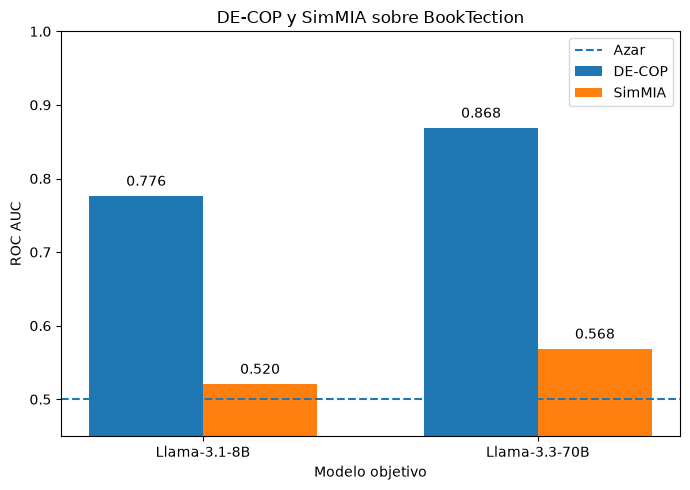

PNG: /Users/florenciazoffi/Desktop/code/sietesemestre/nlp/NLP_Proyecto_Final/simmia_decop/figures/auc_booktection_decop_vs_simmia.png
PDF: /Users/florenciazoffi/Desktop/code/sietesemestre/nlp/NLP_Proyecto_Final/simmia_decop/figures/auc_booktection_decop_vs_simmia.pdf


In [17]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# Directorios
# ---------------------------------------------------------

BASE_DIR = Path.cwd().parent
RESULTS_DIR = BASE_DIR / "results"
FIGURES_DIR = BASE_DIR / "figures"

FIGURES_DIR.mkdir(exist_ok=True)

# ---------------------------------------------------------
# Cargar métricas
# ---------------------------------------------------------

decop_70 = pd.read_csv(
    RESULTS_DIR
    / "decop"
    / "llama-3.3-70b-versatile"
    / "decop_metrics_summary.csv"
).iloc[0]

decop_8 = pd.read_csv(
    RESULTS_DIR
    / "decop"
    / "llama-3.1-8b-instant"
    / "decop_metrics_summary.csv"
).iloc[0]

simmia_70 = pd.read_csv(
    RESULTS_DIR
    / "simmia"
    / "llama-3.3-70b-versatile"
    / "simmia_metrics_summary.csv"
).iloc[0]

simmia_8 = pd.read_csv(
    RESULTS_DIR
    / "simmia"
    / "llama-3.1-8b-instant"
    / "simmia_metrics_summary.csv"
).iloc[0]

# ---------------------------------------------------------
# Tabla resumen
# ---------------------------------------------------------

summary = pd.DataFrame([
    {
        "Modelo": "Llama-3.1-8B",
        "DE-COP": float(decop_8["auc"]),
        "SimMIA": float(simmia_8["auc"]),
    },
    {
        "Modelo": "Llama-3.3-70B",
        "DE-COP": float(decop_70["auc"]),
        "SimMIA": float(simmia_70["auc"]),
    },
])

display(summary)

summary.to_csv(
    FIGURES_DIR / "booktection_methods_summary.csv",
    index=False,
)

# ---------------------------------------------------------
# Gráfico
# ---------------------------------------------------------

models = summary["Modelo"]

decop_auc = summary["DE-COP"]
simmia_auc = summary["SimMIA"]

x = np.arange(len(models))
width = 0.34

fig, ax = plt.subplots(figsize=(7,5))

bars1 = ax.bar(
    x - width/2,
    decop_auc,
    width,
    label="DE-COP",
)

bars2 = ax.bar(
    x + width/2,
    simmia_auc,
    width,
    label="SimMIA",
)

ax.axhline(
    0.5,
    linestyle="--",
    linewidth=1.5,
    label="Azar",
)

ax.set_xticks(x)
ax.set_xticklabels(models)

ax.set_ylabel("ROC AUC")
ax.set_xlabel("Modelo objetivo")
ax.set_title("DE-COP y SimMIA sobre BookTection")
ax.set_ylim(0.45,1.0)

ax.legend()

# Etiquetas encima de cada barra
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.01,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=10,
        )

plt.tight_layout()

png_path = FIGURES_DIR / "auc_booktection_decop_vs_simmia.png"
pdf_path = FIGURES_DIR / "auc_booktection_decop_vs_simmia.pdf"

plt.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    pdf_path,
    bbox_inches="tight",
)

plt.show()

print("PNG:", png_path)
print("PDF:", pdf_path)

In [16]:
wikimia_summary_df = pd.DataFrame([
    {
        "Método": "DE-COP",
        "Modelo": decop_wikimia_metrics["model"],
        "Dataset": decop_wikimia_metrics["split"],
        "AUC": float(decop_wikimia_metrics["auc"]),
        "TPR@5%FPR": (
            float(decop_wikimia_metrics["tpr_at_5_fpr"])
            if "tpr_at_5_fpr" in decop_wikimia_metrics.index
            else None
        ),
        "Muestras": int(decop_wikimia_metrics["n_samples"]),
    },
])

display(wikimia_summary_df)

,Método,Modelo,Dataset,AUC,TPR@5%FPR,Muestras
0,DE-COP,llama-3.1-8b-instant,WikiMIA_length128,0.54865,0.02,200
